# Netflix Movies & TV Shows — Exploratory Data Analysis

## 1. Project Overview

This project performs an exploratory data analysis of Netflix Movies and TV Shows to understand the platform's content distribution, growth trends, genres, ratings, countries, movie durations, TV show seasons, and other patterns.

## 2. Import Libraries

In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 3. Load Dataset

In [99]:
df = pd.read_csv("netflix_titles.csv")

## 4. Data Understanding

In [100]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [101]:
df.tail()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [102]:
df.shape

(8807, 12)

In [103]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [104]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [105]:
df.describe()


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [106]:
df.isnull().sum()


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [107]:
(df.isnull().sum() / len(df) * 100).round(2)

show_id          0.00
type             0.00
title            0.00
director        29.91
cast             9.37
country          9.44
date_added       0.11
release_year     0.00
rating           0.05
duration         0.03
listed_in        0.00
description      0.00
dtype: float64

In [108]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})

missing

,Missing Values,Missing %
show_id,0,0.00
type,0,0.00
title,0,0.00
director,2634,29.91
cast,825,9.37
country,831,9.44
date_added,10,0.11
release_year,0,0.00
rating,4,0.05
duration,3,0.03


In [109]:
df.groupby("type")["director"].apply(lambda x: x.isnull().sum())

type
Movie       188
TV Show    2446
Name: director, dtype: int64

In [110]:
df.groupby("type")["country"].apply(lambda x: x.isnull().sum())

type
Movie      440
TV Show    391
Name: country, dtype: int64

In [111]:
df.groupby("type")["cast"].apply(lambda x: x.isnull().sum())


type
Movie      475
TV Show    350
Name: cast, dtype: int64

In [112]:
df.groupby("type")["director"].apply(
    lambda x: x.isnull().mean() * 100
).round(2)

type
Movie       3.07
TV Show    91.41
Name: director, dtype: float64

In [113]:
df.groupby("type")["country"].apply(
    lambda x: x.isnull().mean() * 100
).round(2)

type
Movie       7.18
TV Show    14.61
Name: country, dtype: float64

In [114]:
df.groupby("type")["cast"].apply(
    lambda x: x.isnull().mean() * 100
).round(2)

type
Movie       7.75
TV Show    13.08
Name: cast, dtype: float64

In [115]:
df.duplicated().sum()

np.int64(0)

In [116]:
(df.duplicated().sum() / len(df) * 100).round(2)

np.float64(0.0)

In [117]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [118]:
df["rating"].value_counts()

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64

In [119]:
df["duration"].unique()[:20]

<ArrowStringArray>
[   '90 min', '2 Seasons',  '1 Season',    '91 min',   '125 min', '9 Seasons',
   '104 min',   '127 min', '4 Seasons',    '67 min',    '94 min', '5 Seasons',
   '161 min',    '61 min',   '166 min',   '147 min',   '103 min',    '97 min',
   '106 min',   '111 min']
Length: 20, dtype: str

In [120]:
df[df["rating"].str.contains("min", na=False)][
    ["title", "type", "rating", "duration"]
]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,NaN
5794,Louis C.K.: Hilarious,Movie,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,NaN


In [121]:
df["rating"].str.contains("min", na=False).sum()

np.int64(3)

## 5. Data Cleaning

Inspect and correct data-quality issues while preserving valid title records. Missing values are reviewed before deciding how to handle them.


In [122]:
mask = df["rating"].str.contains("min", na=False)

In [123]:
df.loc[mask, "duration"] = df.loc[mask, "rating"]

In [124]:
df.loc[mask, "rating"] = np.nan

In [125]:
df[df["title"].str.contains("Louis C.K.", na=False)][
    ["title", "rating", "duration"]
]

,title,rating,duration
5541,Louis C.K. 2017,NaN,74 min
5794,Louis C.K.: Hilarious,NaN,84 min
5813,Louis C.K.: Live at the Comedy Store,NaN,66 min


In [126]:
df["rating"].str.contains("min", na=False).sum()

np.int64(0)

In [127]:
df["date_added"].head(10)

0    September 25, 2021
1    September 24, 2021
2    September 24, 2021
3    September 24, 2021
4    September 24, 2021
5    September 24, 2021
6    September 24, 2021
7    September 24, 2021
8    September 24, 2021
9    September 24, 2021
Name: date_added, dtype: str

In [128]:
df["date_added"].dtype

<StringDtype(na_value=nan)>

In [129]:
df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")

In [130]:
df["date_added"].dtype

dtype('<M8[us]')

In [131]:
df["date_added"].isnull().sum()

np.int64(98)

In [132]:
df["added_year"] = df["date_added"].dt.year
df["added_month"] = df["date_added"].dt.month
df["added_month_name"] = df["date_added"].dt.month_name()

In [133]:
df[["date_added", "added_year", "added_month", "added_month_name"]].head()

,date_added,added_year,added_month,added_month_name
0,2021-09-25,2021.0,9.0,September
1,2021-09-24,2021.0,9.0,September
2,2021-09-24,2021.0,9.0,September
3,2021-09-24,2021.0,9.0,September
4,2021-09-24,2021.0,9.0,September


In [134]:
df["duration_min"] = np.where(
    df["type"] == "Movie",
    df["duration"].str.extract(r"(\d+)")[0].astype(float),
    np.nan
)

In [135]:
df["seasons"] = np.where(
    df["type"] == "TV Show",
    df["duration"].str.extract(r"(\d+)")[0].astype(float),
    np.nan
)

In [136]:
df[["type", "duration", "duration_min", "seasons"]].head(10)


,type,duration,duration_min,seasons
0,Movie,90 min,90.0,NaN
1,TV Show,2 Seasons,NaN,2.0
2,TV Show,1 Season,NaN,1.0
3,TV Show,1 Season,NaN,1.0
4,TV Show,2 Seasons,NaN,2.0
5,TV Show,1 Season,NaN,1.0
6,Movie,91 min,91.0,NaN
7,Movie,125 min,125.0,NaN
8,TV Show,9 Seasons,NaN,9.0
9,Movie,104 min,104.0,NaN


In [137]:
df.groupby("type")[["duration_min", "seasons"]].count()

,duration_min,seasons
type,,
Movie,6131,0
TV Show,0,2676


In [138]:
df[["duration_min", "seasons"]].isnull().sum()

duration_min    2676
seasons         6131
dtype: int64

In [139]:
df[["rating", "date_added", "duration"]].isnull().sum()

rating         7
date_added    98
duration       0
dtype: int64

In [140]:
df["rating"].unique()

<ArrowStringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',        nan,
       'NR', 'TV-Y7-FV',       'UR']
Length: 15, dtype: str

In [141]:
df["duration"].isnull().sum()

np.int64(0)

In [142]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   str           
 1   type              8807 non-null   str           
 2   title             8807 non-null   str           
 3   director          6173 non-null   str           
 4   cast              7982 non-null   str           
 5   country           7976 non-null   str           
 6   date_added        8709 non-null   datetime64[us]
 7   release_year      8807 non-null   int64         
 8   rating            8800 non-null   str           
 9   duration          8807 non-null   str           
 10  listed_in         8807 non-null   str           
 11  description       8807 non-null   str           
 12  added_year        8709 non-null   float64       
 13  added_month       8709 non-null   float64       
 14  added_month_name  8709 non-null   s

In [143]:
df["rating"] = df["rating"].fillna("Unknown")

In [144]:
df["rating"].isnull().sum()

np.int64(0)

In [145]:
df["type"].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [146]:
df["type"].value_counts(normalize=True) * 100

type
Movie      69.615079
TV Show    30.384921
Name: proportion, dtype: float64

## 6. Content Type Overview

Compare the number and proportion of Movies and TV Shows.


Text(0, 0.5, 'Number of Titles')

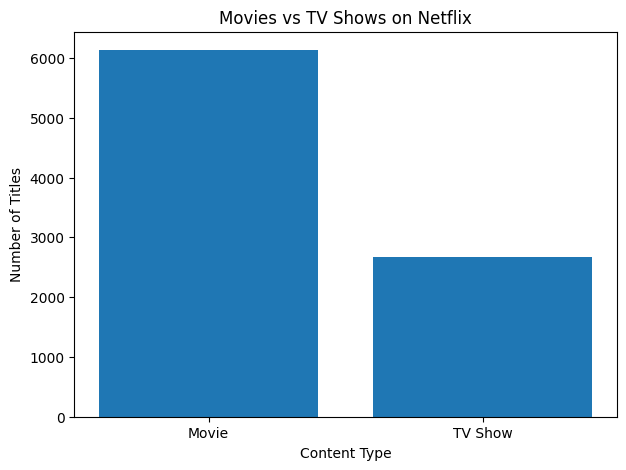

In [147]:
type_counts = df["type"].value_counts()

plt.figure(figsize=(7, 5))
plt.bar(type_counts.index, type_counts.values)

plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

## 7. Netflix Content Addition Trends

Explore when titles were added to Netflix. These trends describe the dataset snapshot, not Netflix’s complete historical catalogue.


In [148]:
yearly_additions = (
    df["added_year"]
    .value_counts()
    .sort_index()
)

yearly_additions

added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

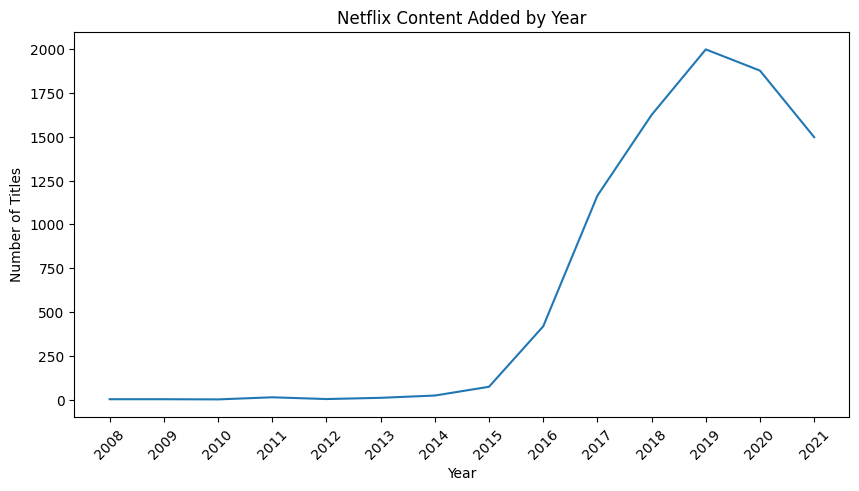

In [149]:
plt.figure(figsize=(10, 5))

plt.plot(yearly_additions.index, yearly_additions.values)

plt.title("Netflix Content Added by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.xticks(yearly_additions.index, rotation=45)

plt.show()

In [150]:
yearly_type = (
    df.dropna(subset=["added_year"])
      .groupby(["added_year", "type"])
      .size()
      .unstack(fill_value=0)
)

yearly_type.tail()

type,Movie,TV Show
added_year,,
2017.0,839,325
2018.0,1237,388
2019.0,1424,575
2020.0,1284,594
2021.0,993,505


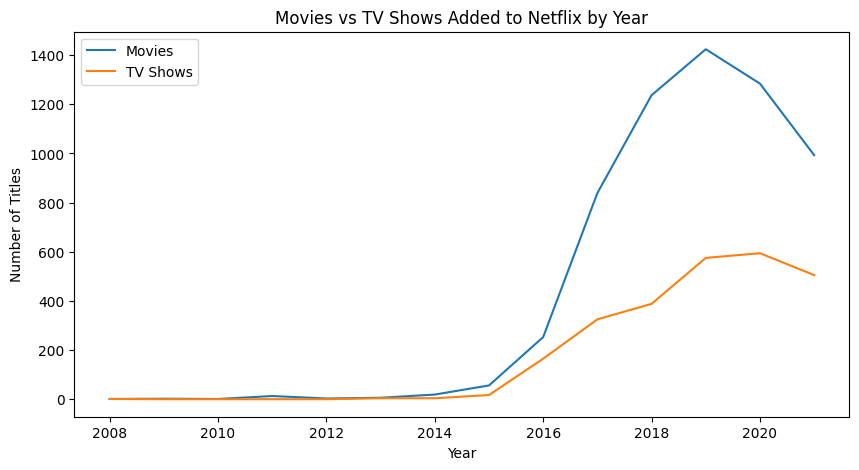

In [151]:
plt.figure(figsize=(10, 5))

plt.plot(yearly_type.index, yearly_type["Movie"], label="Movies")
plt.plot(yearly_type.index, yearly_type["TV Show"], label="TV Shows")

plt.title("Movies vs TV Shows Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")
plt.legend()

plt.show()

## 8. Country Analysis

Country values can contain multiple countries; after splitting them, one title may contribute to more than one country.


In [152]:
country_counts = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

country_counts.head(10)

country
United States     3689
India             1046
United Kingdom     804
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

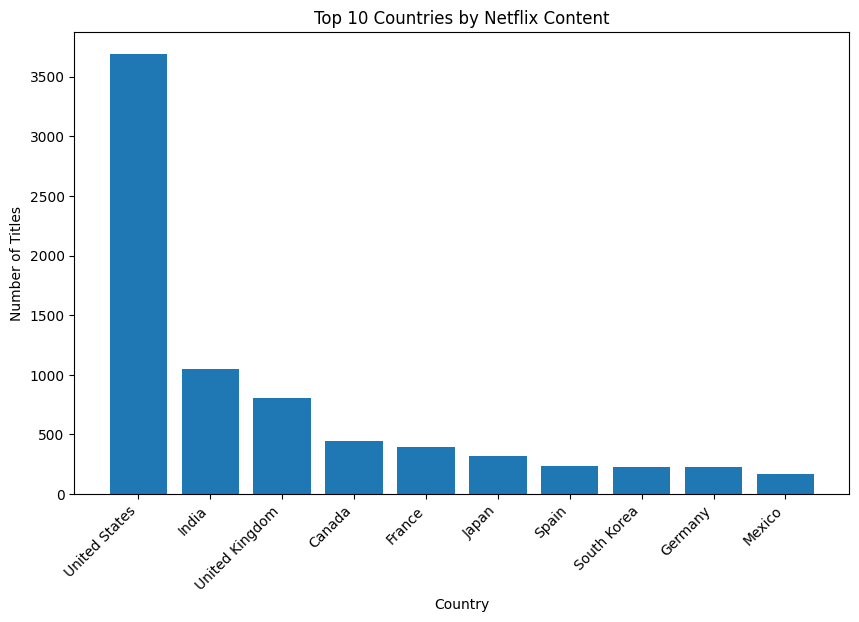

In [153]:
top_countries = country_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_countries.index, top_countries.values)

plt.title("Top 10 Countries by Netflix Content")
plt.xlabel("Country")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.show()

## 9. India-Associated Content

Titles with “India” anywhere in the country field are included. This does not mean every selected title was produced exclusively in India.


In [154]:
india_content = df[
    df["country"].str.contains("India", na=False)
]

len(india_content)

1046

In [155]:
india_content["type"].value_counts()

type
Movie      962
TV Show     84
Name: count, dtype: int64

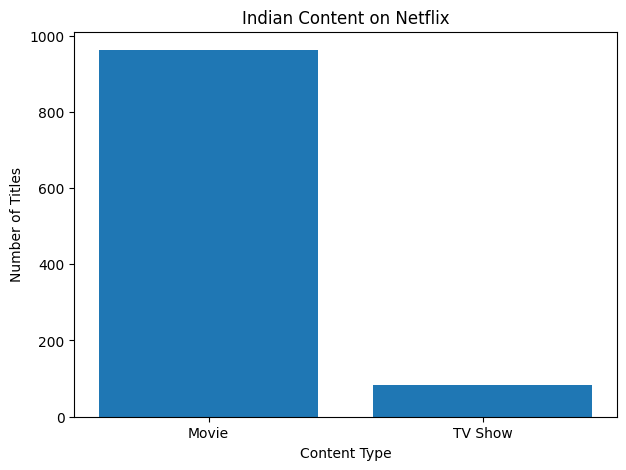

In [156]:
india_type_counts = india_content["type"].value_counts()

plt.figure(figsize=(7, 5))

plt.bar(india_type_counts.index, india_type_counts.values)

plt.title("Indian Content on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.show()

In [157]:
india_yearly = (
    india_content
    .dropna(subset=["added_year"])
    .groupby("added_year")
    .size()
)

india_yearly

added_year
2016.0     13
2017.0    161
2018.0    349
2019.0    218
2020.0    199
2021.0    105
dtype: int64

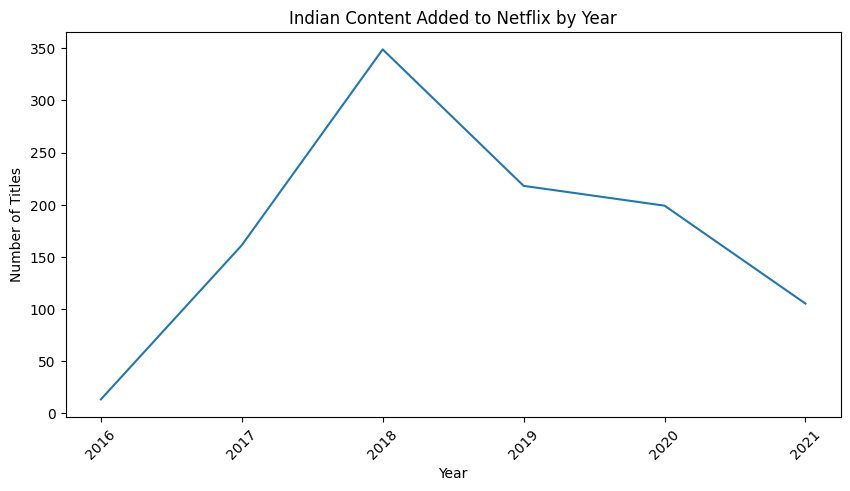

In [158]:
plt.figure(figsize=(10, 5))

plt.plot(india_yearly.index, india_yearly.values)

plt.title("Indian Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.xticks(india_yearly.index, rotation=45)

plt.show()

## 10. Genre Analysis

Each title may belong to multiple listed genres, so genre counts can exceed the number of unique titles.


In [159]:
genre_counts = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

genre_counts.head(15)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
Name: count, dtype: int64

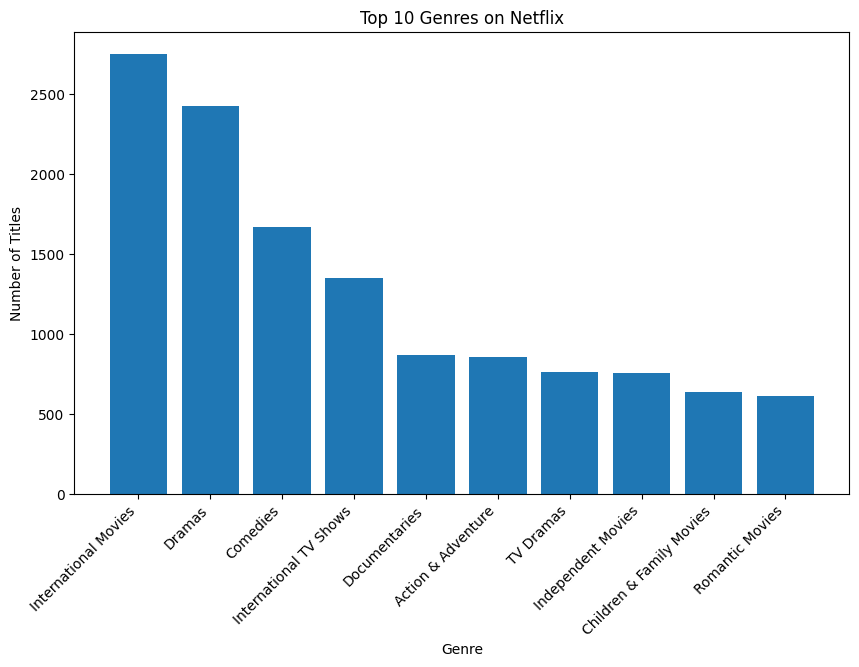

In [160]:
top_genres = genre_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_genres.index, top_genres.values)

plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.show()

In [161]:
movie_genres = (
    df[df["type"] == "Movie"]["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

movie_genres.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Name: count, dtype: int64

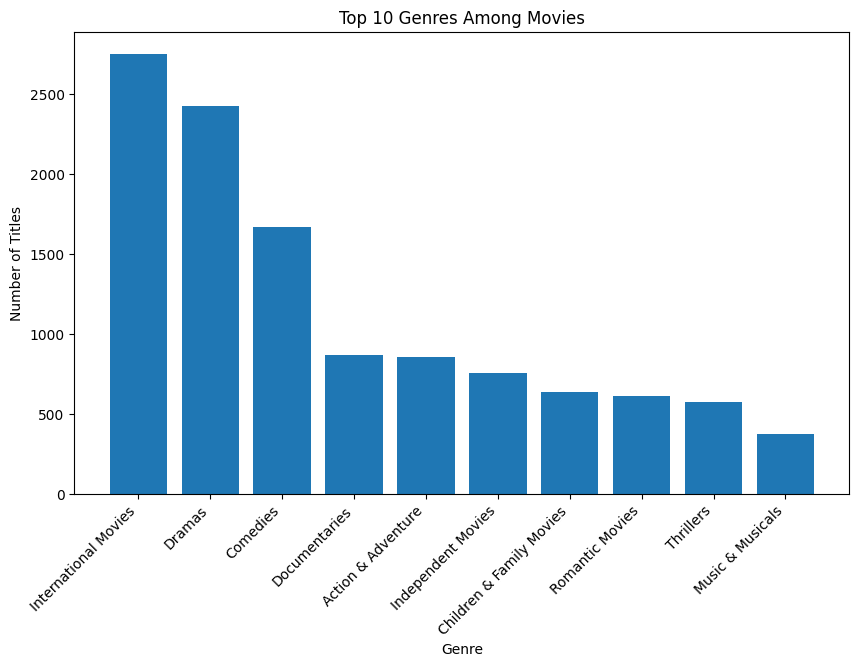

In [162]:
plt.figure(figsize=(10, 6))

plt.bar(movie_genres.head(10).index, movie_genres.head(10).values)

plt.title("Top 10 Genres Among Movies")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.show()

In [163]:
tv_genres = (
    df[df["type"] == "TV Show"]["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

tv_genres.head(10)

listed_in
International TV Shows    1351
TV Dramas                  763
TV Comedies                581
Crime TV Shows             470
Kids' TV                   451
Docuseries                 395
Romantic TV Shows          370
Reality TV                 255
British TV Shows           253
Anime Series               176
Name: count, dtype: int64

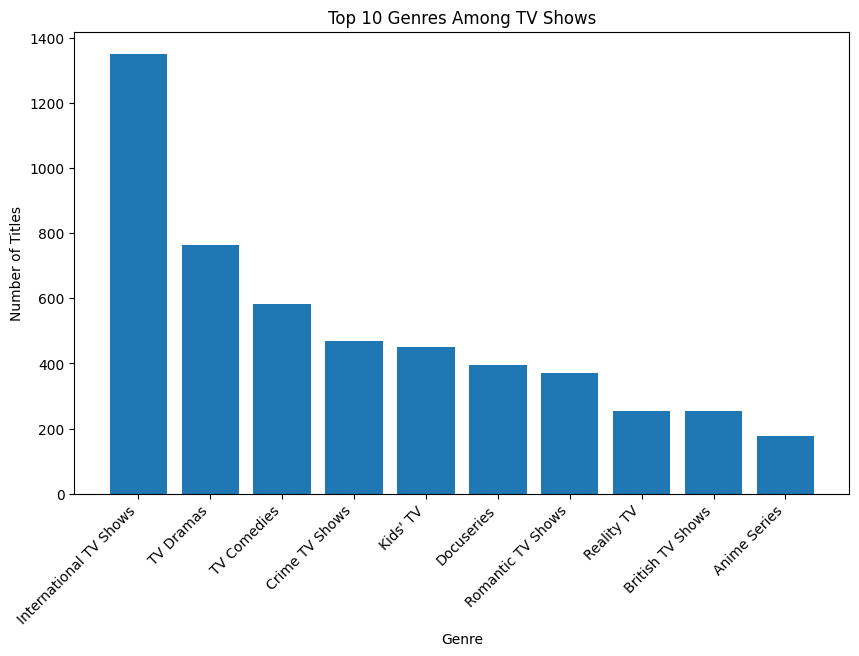

In [164]:
plt.figure(figsize=(10, 6))

plt.bar(tv_genres.head(10).index, tv_genres.head(10).values)

plt.title("Top 10 Genres Among TV Shows")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.show()

## 11. Content Rating Analysis

Ratings are grouped as provided in the dataset. Movie and TV rating labels are not perfectly equivalent across systems.


In [165]:
rating_counts = df["rating"].value_counts()

rating_counts

rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

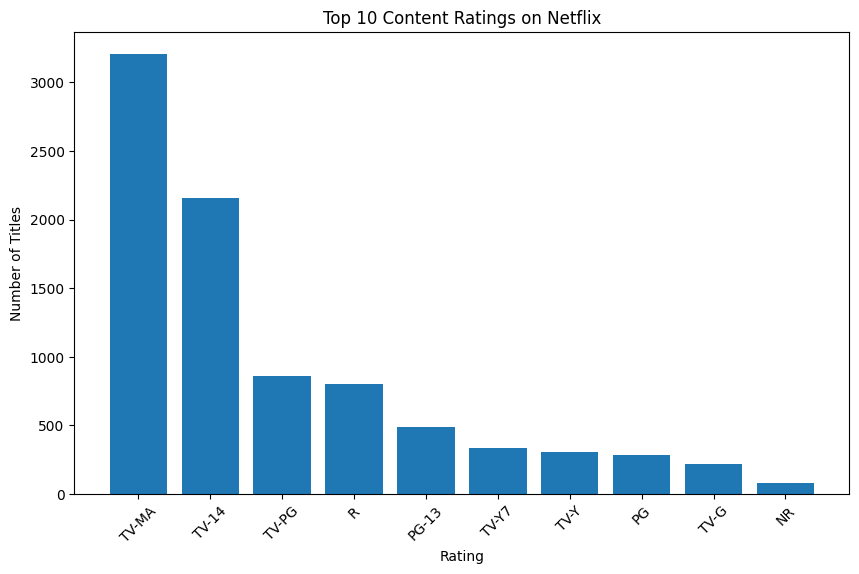

In [166]:
top_ratings = rating_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_ratings.index, top_ratings.values)

plt.title("Top 10 Content Ratings on Netflix")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)

plt.show()

In [167]:
rating_by_type = (
    df.groupby(["rating", "type"])
      .size()
      .unstack(fill_value=0)
)

rating_by_type

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,5
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,733
TV-G,126,94
TV-MA,2062,1145


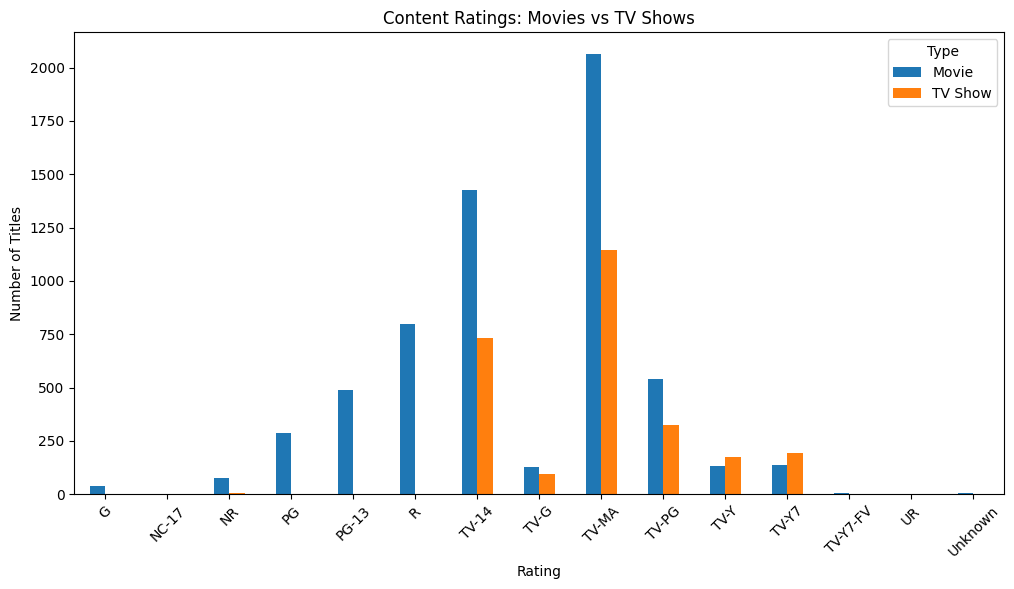

In [168]:
rating_by_type.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Content Ratings: Movies vs TV Shows")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)

plt.legend(title="Type")
plt.show()

## 12. Movie Duration and TV Show Seasons

Movie duration is measured in minutes; TV Show duration is represented by season count. The engineered columns are intentionally missing for the opposite content type.


In [169]:
df["duration_min"].describe()

count    6131.000000
mean       99.564998
std        28.289504
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

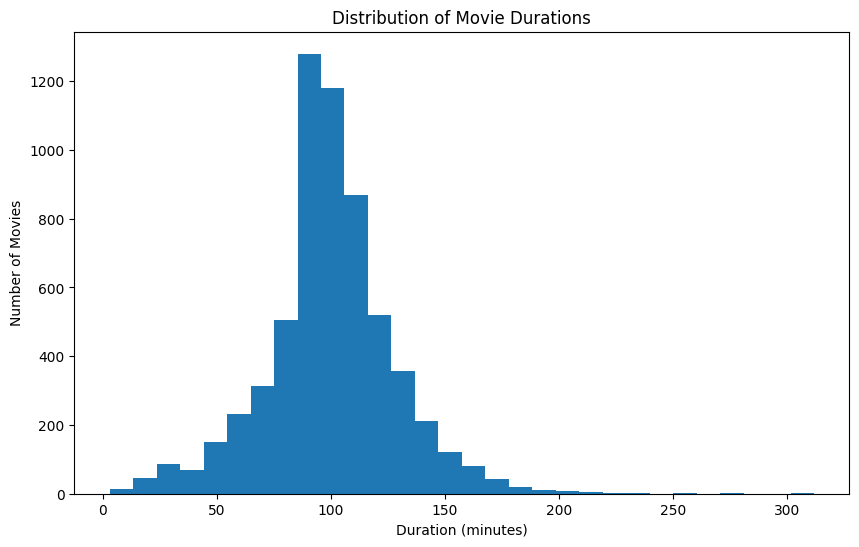

In [170]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["duration_min"].dropna(),
    bins=30
)

plt.title("Distribution of Movie Durations")
plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.show()

In [171]:
df["seasons"].describe()

count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: seasons, dtype: float64

In [172]:
season_counts = df["seasons"].value_counts().sort_index()

season_counts

seasons
1.0     1793
2.0      425
3.0      199
4.0       95
5.0       65
6.0       33
7.0       23
8.0       17
9.0        9
10.0       7
11.0       2
12.0       2
13.0       3
15.0       2
17.0       1
Name: count, dtype: int64

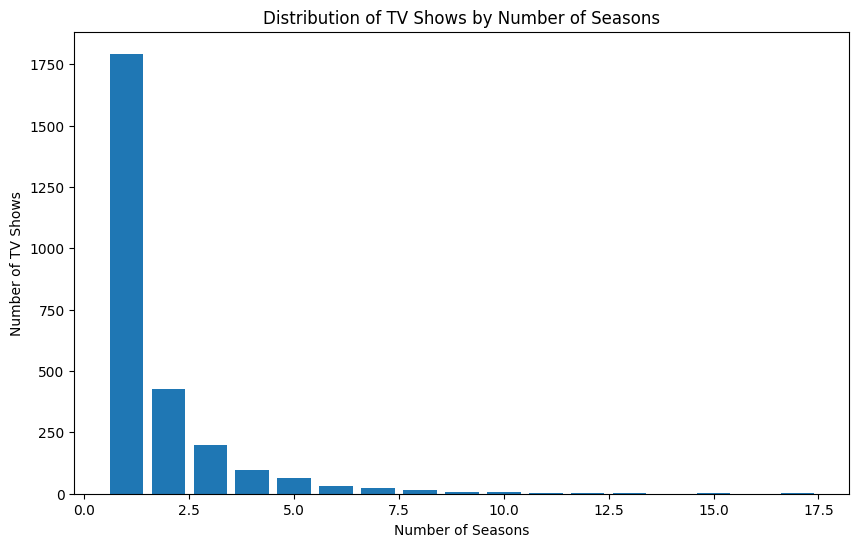

In [173]:
plt.figure(figsize=(10, 6))

plt.bar(season_counts.index, season_counts.values)

plt.title("Distribution of TV Shows by Number of Seasons")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")

plt.show()

## 13. Release Year Analysis

This section examines the release years represented in the catalogue, separately from the year Netflix added a title.


In [174]:
release_year_counts = df["release_year"].value_counts().sort_index()

release_year_counts.tail(20)

release_year
2002      51
2003      61
2004      64
2005      80
2006      96
2007      88
2008     136
2009     152
2010     194
2011     185
2012     237
2013     288
2014     352
2015     560
2016     902
2017    1032
2018    1147
2019    1030
2020     953
2021     592
Name: count, dtype: int64

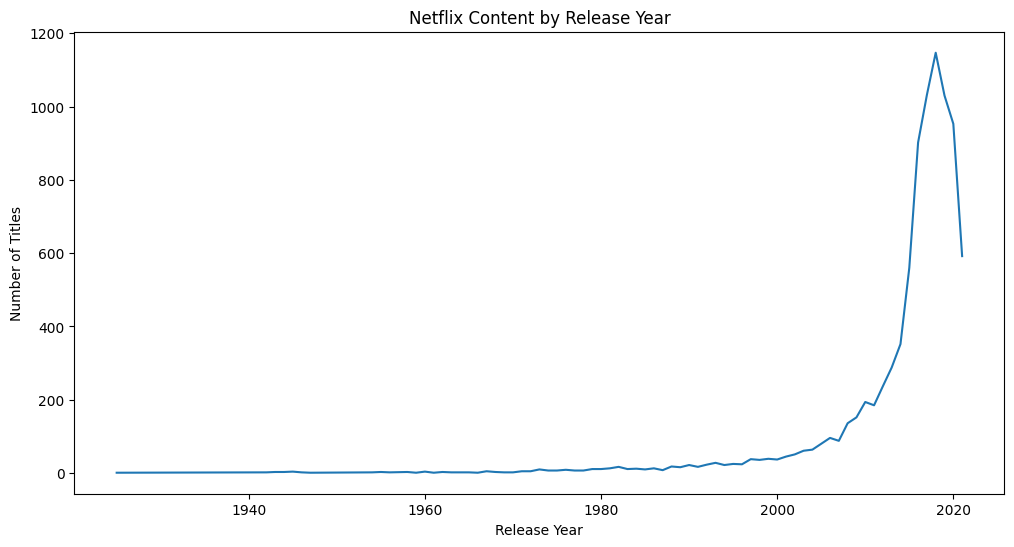

In [175]:
plt.figure(figsize=(12, 6))

plt.plot(
    release_year_counts.index,
    release_year_counts.values
)

plt.title("Netflix Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")

plt.show()

In [176]:
df["release_decade"] = (df["release_year"] // 10) * 10

In [177]:
decade_counts = df["release_decade"].value_counts().sort_index()

decade_counts

release_decade
1920       1
1940      15
1950      11
1960      25
1970      70
1980     129
1990     274
2000     810
2010    5927
2020    1545
Name: count, dtype: int64

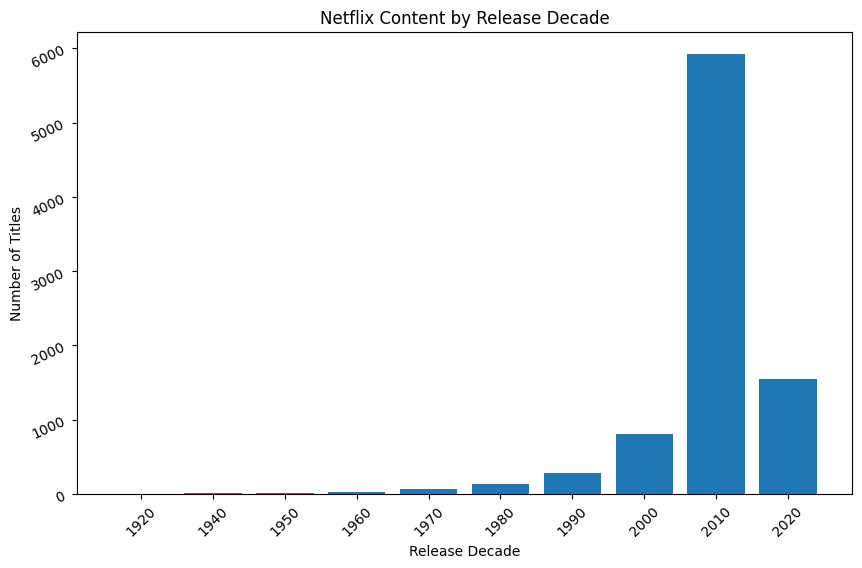

In [178]:
plt.figure(figsize=(10, 6))

plt.bar(decade_counts.index.astype(str), decade_counts.values)

plt.title("Netflix Content by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45)
plt.yticks(rotation=25)
plt.show()

## 14. Release-to-Netflix Addition Gap

The gap is estimated using calendar years only, so it is approximate. Negative values should be inspected as potential date/data anomalies rather than automatically removed.


In [179]:
df["years_to_netflix"] = df["added_year"] - df["release_year"]

In [180]:
df["years_to_netflix"].describe()

count    8709.000000
mean        4.690894
std         8.792208
min        -3.000000
25%         0.000000
50%         1.000000
75%         5.000000
max        93.000000
Name: years_to_netflix, dtype: float64

In [181]:
(df["years_to_netflix"] < 0).sum()

np.int64(14)

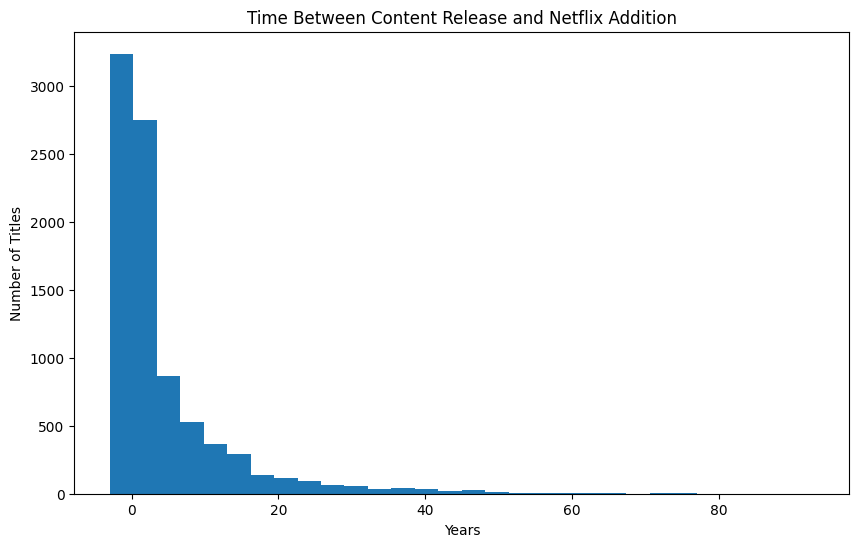

In [182]:
plt.figure(figsize=(10, 6))

plt.hist(
    df["years_to_netflix"].dropna(),
    bins=30
)

plt.title("Time Between Content Release and Netflix Addition")
plt.xlabel("Years")
plt.ylabel("Number of Titles")

plt.show()

## 15. Month and Contributor Analysis

Compare additions by calendar month and review frequently listed directors and cast members. These counts reflect metadata listings, not popularity or lead roles.


In [183]:
monthly_additions = (
    df.dropna(subset=["added_month"])
      .groupby("added_month")
      .size()
)

monthly_additions

added_month
1.0     727
2.0     557
3.0     734
4.0     759
5.0     626
6.0     724
7.0     819
8.0     749
9.0     765
10.0    755
11.0    697
12.0    797
dtype: int64

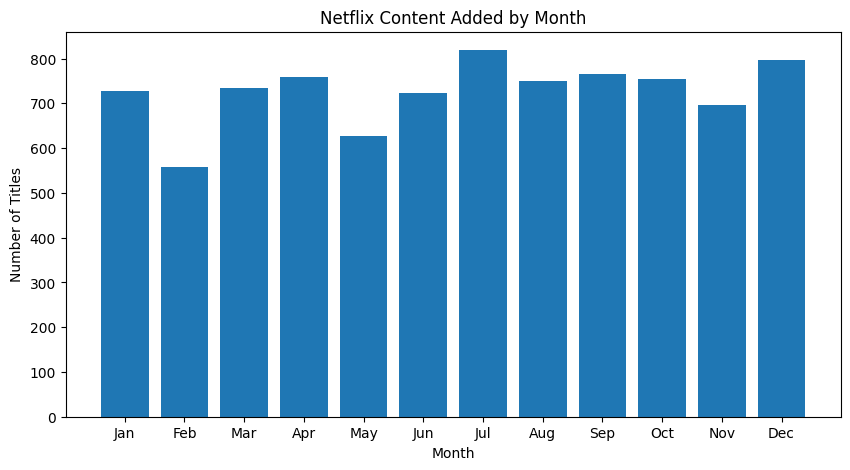

In [184]:
plt.figure(figsize=(10, 5))

plt.bar(monthly_additions.index, monthly_additions.values)

plt.title("Netflix Content Added by Month")
plt.xlabel("Month")
plt.ylabel("Number of Titles")

plt.xticks(
    range(1, 13),
    ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
     "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
)

plt.show()

In [185]:
movie_directors = (
    df[df["type"] == "Movie"]["director"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

movie_directors.head(10)

director
Rajiv Chilaka          22
Jan Suter              21
Raúl Campos            19
Suhas Kadav            16
Jay Karas              15
Marcus Raboy           15
Cathy Garcia-Molina    13
Youssef Chahine        12
Martin Scorsese        12
Jay Chapman            12
Name: count, dtype: int64

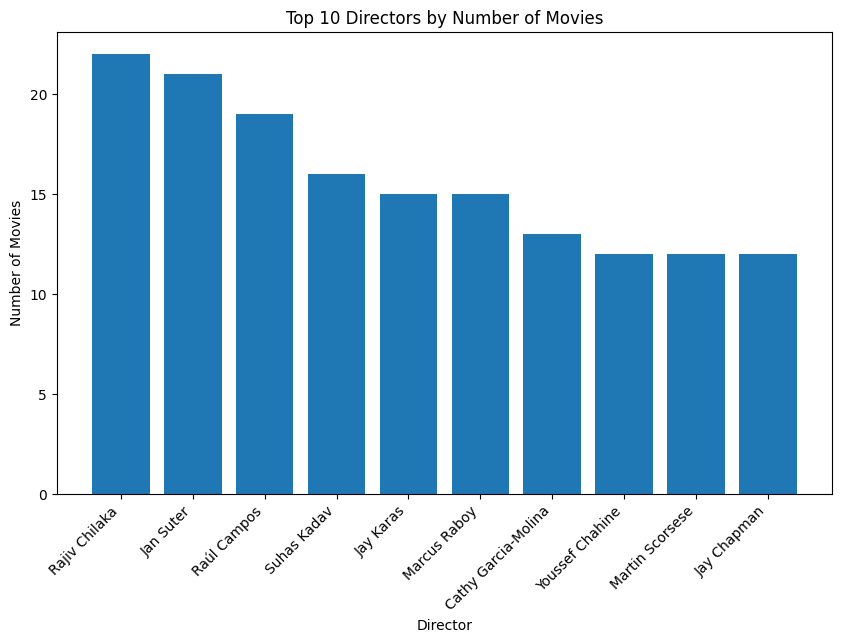

In [186]:
top_directors = movie_directors.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_directors.index, top_directors.values)

plt.title("Top 10 Directors by Number of Movies")
plt.xlabel("Director")
plt.ylabel("Number of Movies")

plt.xticks(rotation=45, ha="right")

plt.show()

In [187]:
actor_counts = (
    df["cast"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

actor_counts.head(10)

cast
Anupam Kher         43
Shah Rukh Khan      35
Julie Tejwani       33
Naseeruddin Shah    32
Takahiro Sakurai    32
Rupa Bhimani        31
Akshay Kumar        30
Om Puri             30
Yuki Kaji           29
Amitabh Bachchan    28
Name: count, dtype: int64

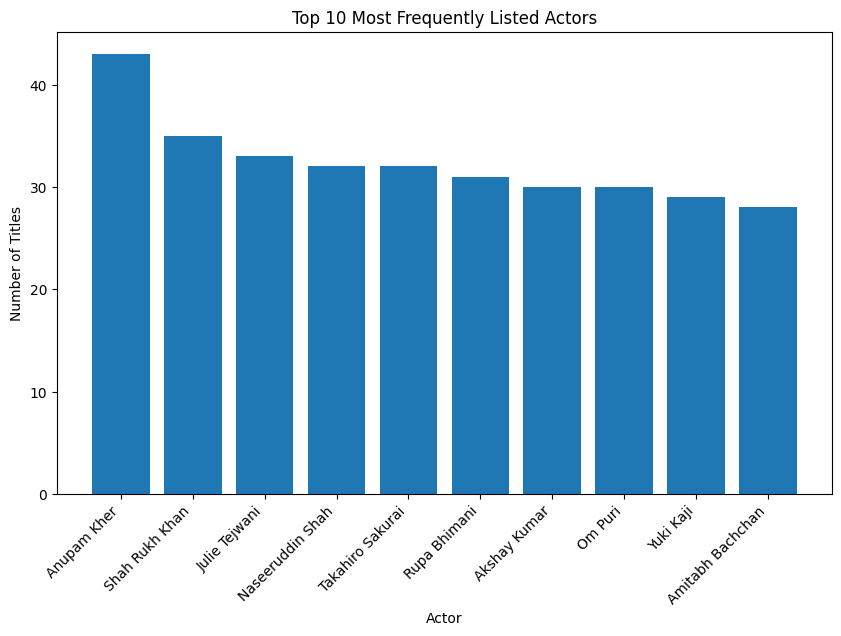

In [188]:
top_actors = actor_counts.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_actors.index, top_actors.values)

plt.title("Top 10 Most Frequently Listed Actors")
plt.xlabel("Actor")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.show()

In [189]:
india_genres = (
    india_content["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
)

india_genres.head(10)

listed_in
International Movies      864
Dramas                    662
Comedies                  323
Independent Movies        167
Action & Adventure        137
Romantic Movies           120
Music & Musicals           96
Thrillers                  92
International TV Shows     66
Horror Movies              35
Name: count, dtype: int64

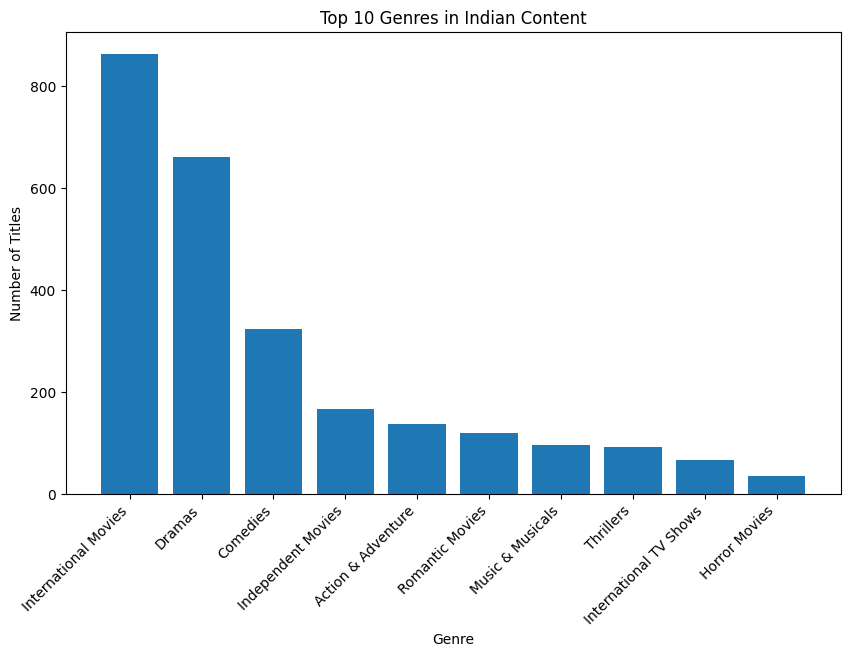

In [190]:
top_india_genres = india_genres.head(10)

plt.figure(figsize=(10, 6))

plt.bar(top_india_genres.index, top_india_genres.values)

plt.title("Top 10 Genres in Indian Content")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")

plt.xticks(rotation=45, ha="right")

plt.show()

## 16. Executive Summary

A compact set of dataset-level statistics to close the analysis.


In [191]:
total_titles = len(df)

total_movies = (df["type"] == "Movie").sum()
total_tv_shows = (df["type"] == "TV Show").sum()

latest_release_year = df["release_year"].max()
earliest_release_year = df["release_year"].min()

top_country = country_counts.index[0]
top_genre = genre_counts.index[0]
top_rating = rating_counts.index[0]

print("Total Titles:", total_titles)
print("Movies:", total_movies)
print("TV Shows:", total_tv_shows)
print("Earliest Release Year:", earliest_release_year)
print("Latest Release Year:", latest_release_year)
print("Top Country:", top_country)
print("Top Genre:", top_genre)
print("Most Common Rating:", top_rating)

Total Titles: 8807
Movies: 6131
TV Shows: 2676
Earliest Release Year: 1925
Latest Release Year: 2021
Top Country: United States
Top Genre: International Movies
Most Common Rating: TV-MA


In [192]:
type_percentage = (
    df["type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

type_percentage

type
Movie      69.62
TV Show    30.38
Name: proportion, dtype: float64

In [193]:
india_percentage = round(
    len(india_content) / len(df) * 100,
    2
)

print("Indian-associated titles:", len(india_content))
print("Percentage:", india_percentage, "%")

Indian-associated titles: 1046
Percentage: 11.88 %


In [194]:
movie_pct = (df["type"].eq("Movie").mean() * 100).round(2)
tv_pct = (df["type"].eq("TV Show").mean() * 100).round(2)
median_movie_duration = df.loc[df["type"].eq("Movie"), "duration_min"].median()
median_tv_seasons = df.loc[df["type"].eq("TV Show"), "seasons"].median()

print(f"The dataset contains {len(df):,} titles: {total_movies:,} Movies ({movie_pct}%) and {total_tv_shows:,} TV Shows ({tv_pct}%).")
print(f"The most frequently listed country is {top_country}; multi-country titles can contribute to multiple country counts.")
print(f"The most common listed genre is {top_genre}; titles can belong to multiple genres.")
print(f"The most common content rating label is {top_rating}.")
print(f"Median movie duration: {median_movie_duration:.0f} minutes.")
print(f"Median TV show length: {median_tv_seasons:.0f} season(s).")
print(f"Titles associated with India: {len(india_content):,} ({india_percentage}% of the dataset).")
print(f"Exact duplicate rows: {df.duplicated().sum()}.")

The dataset contains 8,807 titles: 6,131 Movies (69.62%) and 2,676 TV Shows (30.38%).
The most frequently listed country is United States; multi-country titles can contribute to multiple country counts.
The most common listed genre is International Movies; titles can belong to multiple genres.
The most common content rating label is TV-MA.
Median movie duration: 98 minutes.
Median TV show length: 1 season(s).
Titles associated with India: 1,046 (11.88% of the dataset).
Exact duplicate rows: 0.


## 17. Key Takeaways and Limitations

The cell below summarizes findings directly from the cleaned dataset. Counts for countries and genres may overlap because one title can list multiple countries or genres. The release-to-addition gap uses calendar years only, so it is approximate. Ratings use different classification systems for movies and TV shows. Missing metadata does not necessarily indicate a problem with the title, and this catalogue snapshot does not establish current availability on Netflix.


## Conclusion

This project explored Netflix Movies and TV Shows using Exploratory Data Analysis (EDA).

Key takeaways:
- Movies make up a larger share of the dataset than TV Shows.
- Content additions recorded in the dataset peaked in 2019.
- International Movies, Dramas, and Comedies are among the most frequently listed genres.

Data cleaning and feature engineering helped prepare the dataset for analysis and visualization.

Overall, this project strengthened practical skills in Python, Pandas, NumPy, data cleaning, exploratory data analysis, and data visualization.

*These findings describe the available dataset and do not necessarily represent Netflix's current catalog or overall production trends.*